# California Housing – Regression

## Mål
Målet med uppgiften är att bygga en modell som kan förutsäga `median_house_value`, alltså ungefär vad bostäder är värda i olika områden i Kalifornien.

## Problemtyp
Detta är ett regressionsproblem eftersom vi försöker förutsäga ett numeriskt värde, inte en klass.

## Syfte
Tanken är att modellen ska kunna användas som ett enkelt beslutsstöd, till exempel för att få en ungefärlig bild av vilka områden som är dyrare eller billigare.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Dataförståelse och EDA

Datasetet innehåller information om olika områden i Kalifornien, till exempel geografi, antal hushåll, inkomst och närhet till hav.
Här undersöker vi datan för att få en bättre bild av hur den ser ut innan vi börjar modellera.

In [2]:
print("Datasetstorlek:", df.shape)


num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

print("\nSammanfattning:")
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print(f"Numeriska variabler: {len(num_cols)}")
print(f"Kategoriska variabler: {len(cat_cols)}")
print("\nTarget-variabel:", "median_house_value")



Datasetstorlek: (20640, 10)

Sammanfattning:
Antal rader: 20640
Antal kolumner: 10
Numeriska variabler: 9
Kategoriska variabler: 1

Target-variabel: median_house_value


### Saknade värden

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("\nSaknade värden:")
if len(missing) > 0:
    print(missing)
else:
    print("Inga saknade värden")


Saknade värden:
total_bedrooms    207
dtype: int64


Det finns saknade värden i total_bedrooms (207 st). Eftersom vi skapar variabeln bedrooms_per_room baserat på denna kolumn får även den saknade värden.
Eftersom andelen saknade värden är liten väljer vi att hantera detta med imputering istället för att ta bort rader.

## Fördelning av target

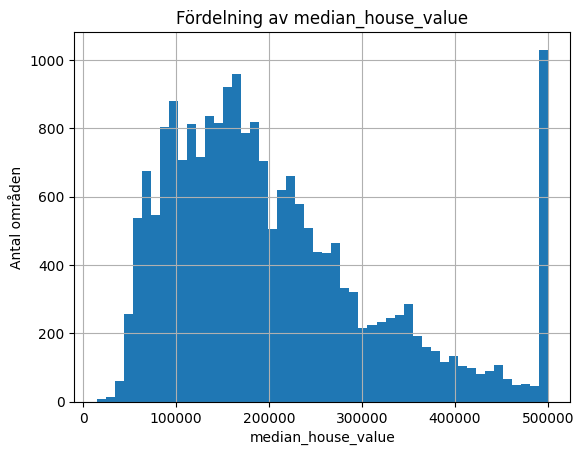

In [4]:
plt.figure()
df["median_house_value"].hist(bins=50)
plt.title("Fördelning av median_house_value")
plt.xlabel("median_house_value")
plt.ylabel("Antal områden")
plt.show()

Histogrammet visar att bostadsvärdena inte är jämnt fördelade. Det finns fler områden med lägre värden och färre med väldigt höga värden.
Man kan också se att det finns ett tak i datan, vilket gör att de högsta värdena klumpas ihop.

## Geografiska mönster

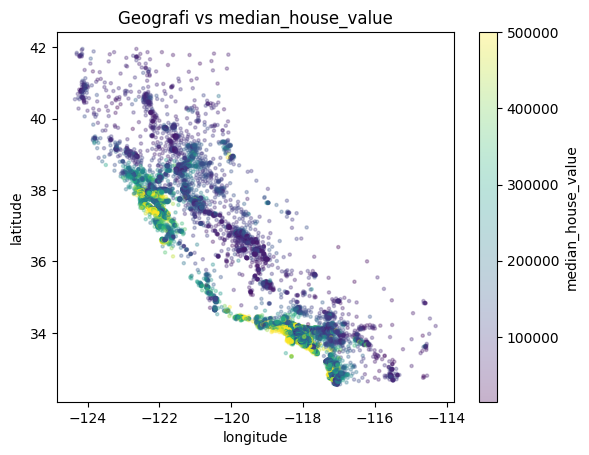

In [5]:
plt.figure()
plt.scatter(df["longitude"], df["latitude"], s=5, alpha=0.3, c=df["median_house_value"])
plt.title("Geografi vs median_house_value")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar(label="median_house_value")
plt.show()

När vi plotterar data på en karta ser vi tydligt att läget spelar stor roll.
Områden nära kusten verkar ha högre bostadsvärden än områden längre in i landet.

## Feature engineering

Vissa variabler är totalsummor per område, så vi skapar nya variabler som ger mer information per hushåll.

Till exempel:
- rum per hushåll
- sovrum per rum
- personer per hushåll

Detta kan hjälpa modellen att förstå datan bättre.

In [6]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

### Definiera target & features

In [7]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

## Train/test-split

Datan delas upp i träningsdata och testdata.
Träningsdatan används för att bygga modellen, och testdatan används för att se hur bra modellen fungerar på ny data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Dela upp numeriska & kategoriska features

In [9]:
num_features = X.select_dtypes(include=["float64"]).columns
cat_features = X.select_dtypes(include=["object", "string"]).columns

## Preprocessing

För att hantera datan på ett korrekt sätt används en pipeline.

Numeriska variabler:
- saknade värden fylls med median
- värdena skalas

Kategoriska variabler:
- saknade värden fylls med vanligaste värdet
- omvandlas till siffror med OneHotEncoding

Detta gör att samma steg används både vid träning och test.

In [10]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

## Modellering – val av modeller

Vi testar flera modeller för att se vilken som fungerar bäst:

- Baseline (DummyRegressor)
- Linear Regression
- Random Forest

Eftersom detta är ett regressionsproblem använder vi RMSE och R² för att jämföra modellerna.

In [11]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

linreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

### Utvärdering

Vi använder två mått:

- RMSE: visar ungefär hur mycket modellen har fel i sina prediktioner
- R²: visar hur bra modellen förklarar variationen i datan

RMSE är lätt att tolka eftersom det är i samma enhet som bostadspriserna.

In [12]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return rmse, r2

## Träna och jämföra modeller

In [13]:
models = {
    "Baseline": baseline,
    "LinearRegression": linreg,
    "RandomForest": rf
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    rmse, r2 = evaluate(model, X_test, y_test)
    
    results.append({
        "model": name,
        "RMSE": rmse,
        "R2": r2
    })

pd.DataFrame(results)

,model,RMSE,R2
0,Baseline,114485.635431,-0.000219
1,LinearRegression,69127.038299,0.635339
2,RandomForest,49833.732394,0.810487


### Val av slutmodell

Random Forest valdes som slutmodell. Den har både lägst RMSE och högst R², vilket innebär att den gör minst prediktionsfel och förklarar störst del av variationen i bostadsvärdena.

## Cross-validation

För att få en mer stabil utvärdering testar vi modellen flera gånger på olika delar av datan.

In [14]:
scores = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)
print("RMSE (CV):", -scores.mean())

RMSE (CV): 50215.58914159306


Cross-validation genomfördes på Random Forest (slutmodellen)

## Robusthet

Resultatet från cross-validation ligger nära resultatet på testdatan.
Det tyder på att modellen är relativt stabil och inte överanpassar träningsdatan. 
Det innebär att modellen sannolikt fungerar ungefär lika bra på ny data.

## Hyperparameter tuning

In [15]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': None, 'model__n_estimators': 100}


Resultatet visar att modellen fungerar bäst med 100 träd och utan begränsning på djupet. 
Det tyder på att en mer flexibel modell fångar datans mönster bättre.

## Oövervakad inlärning – KMeans

Här testar vi om det finns naturliga grupper i datan, utan att använda target-variabeln.
Syftet är att se om områden kan delas in i olika typer, till exempel baserat på inkomst, befolkning eller geografi.

In [16]:
X_unsup = X.select_dtypes(include=["float64"]).copy()

imputer = SimpleImputer(strategy="median")
X_unsup = imputer.fit_transform(X_unsup)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters

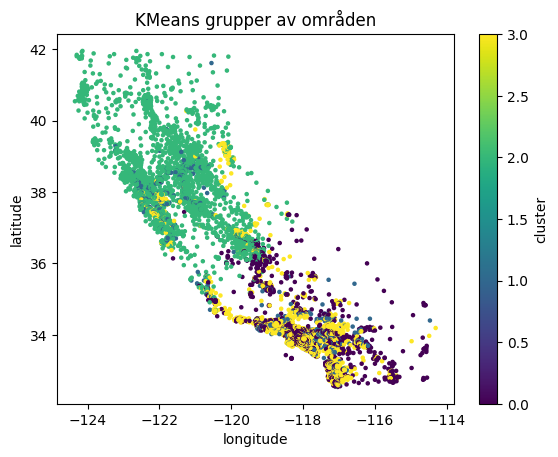

In [17]:
plt.figure()
plt.scatter(df["longitude"], df["latitude"], c=df["cluster"], cmap="viridis", s=5)
plt.title("KMeans grupper av områden")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar(label="cluster")
plt.show()

Resultatet från KMeans visar att områden i Kalifornien kan delas in i flera tydliga grupper.
Grupperna verkar till stor del följa geografiska mönster. Till exempel syns kluster längs kusten och andra mer inåt landet. Detta tyder på att läge är en viktig faktor som skiljer områden åt.
Det är också troligt att klustren skiljer sig i andra variabler, som inkomst och befolkning, även om det inte syns direkt i denna figur.
Detta kan användas som beslutsstöd för att identifiera olika typer av områden, till exempel dyrare kustnära områden jämfört med billigare inland.
Dock är det viktigt att komma ihåg att klustring inte alltid är helt tydlig att tolka, och resultatet påverkas av hur många grupper man väljer.

## Slutsats

Modellen kan användas för att göra ungefärliga uppskattningar av bostadsvärden i olika områden.
Den fångar viktiga mönster i datan, särskilt kopplade till inkomst och geografiskt läge.

### Rekommendation

Modellen kan användas som ett beslutsstöd för att uppskatta bostadsvärden på områdesnivå. 
Den är särskilt användbar för att identifiera områden med högt eller lågt värde inför investeringar.

Dock bör modellen inte användas för exakta värderingar av enskilda bostäder.

## Kritisk diskussion

Det finns några saker som kan påverka hur bra modellen fungerar i verkligheten.
Eftersom datan är aggregerad per område kan modellen missa detaljer som gäller enskilda bostäder. 
Det kan också finnas skillnader mellan olika regioner som modellen inte fångar fullt ut.
Det finns även en risk att modellen fungerar sämre på ny data om mönstren förändras över tid.

Som nästa steg skulle modellen kunna förbättras genom att:
- testa fler modeller
- använda mer data
- göra mer avancerad feature engineering